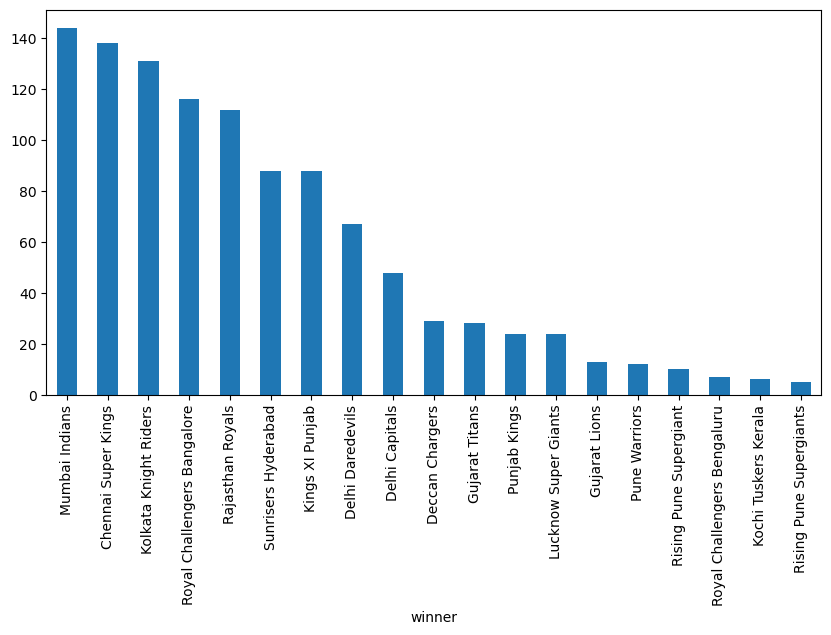

Accuracy: 0.47706422018348627

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.62      0.65        37
           1       0.50      1.00      0.67         2
           2       0.20      0.14      0.17         7
           3       0.46      0.46      0.46        13
           4       0.50      0.40      0.44         5
           5       0.33      0.11      0.17         9
           6       0.37      0.41      0.39        17
           7       0.00      0.00      0.00         2
           8       0.50      0.52      0.51        23
           9       0.40      0.67      0.50         3
          10       0.50      0.54      0.52        26
          11       0.33      0.33      0.33         3
          12       0.00      0.00      0.00         3
          13       0.56      0.56      0.56        25
          14       0.50      0.25      0.33         4
          16       0.37      0.38      0.38        26
          17       0.00   

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Imporved Accuracy: 0.47706422018348627
model saves as ipl_model_winner.pkl
predicted winner(encoded number): 18
predicted winner(team name): Sunrisers Hyderabad


Access is denied.


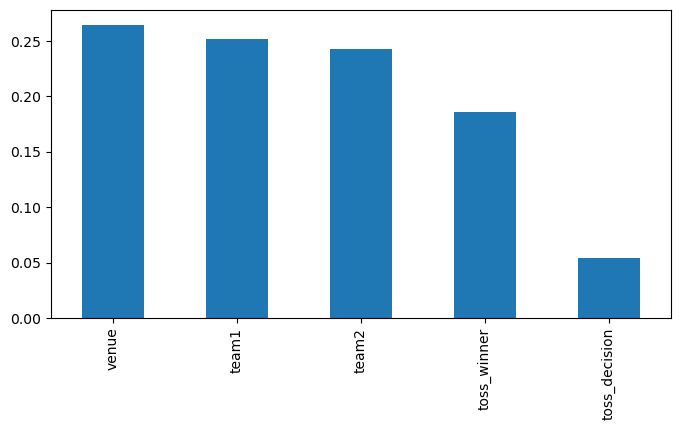

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("C:/Users/shyam/OneDrive/Desktop/IPL_Projects/data/matches.csv.csv")
df.head()
df.columns
important_cols=['team1','team2','toss_winner','toss_decision','venue','winner']
df2=df[important_cols]
df2.head()
df2['winner'].value_counts()
df2=df2.dropna(subset=['winner'])
df2.shape
df2['winner'].value_counts().plot(kind='bar',figsize=(10,5))
plt.show()
from sklearn.preprocessing import LabelEncoder

df3=df2.copy()
encoders={}

for col in ['team1','team2','toss_winner','toss_decision','venue','winner']:
    le=LabelEncoder()
    df3[col]=le.fit_transform(df3[col])
    encoders[col]=le#save encoder for later use
    df3.head()

from sklearn.model_selection import train_test_split
x=df3.drop('winner',axis=1)#input features
y=df3['winner']#target output
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
#creat a model
model=RandomForestClassifier(random_state=42)
model.fit(x_train,y_train)#train model 
y_pred=model.predict(x_test)#test it

#check accuracy
print("Accuracy:",accuracy_score(y_test,y_pred))
#show deatailed report
print("\nClassification Report:\n",classification_report(y_test,y_pred))
feature_importance=pd.Series(model.feature_importances_,index=x.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar',figsize=(8,4))

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
#try to bulid strong model with more tress and controllled depth
tuned_model=RandomForestClassifier(n_estimators=500,max_depth=15,
                                  min_samples_split=4,random_state=42)#more tress,controlcomplexity
tuned_model.fit(x_train,y_train)#train again
y_pred2=tuned_model.predict(x_test)#prediction
print("Imporved Accuracy:",accuracy_score(y_test,y_pred))#check new accuracy
import joblib
joblib.dump(tuned_model,'ipl_model_winner')
print("model saves as ipl_model_winner.pkl")

sample=x_test.iloc[0:1]
pred=tuned_model.predict(sample)
print("predicted winner(encoded number):",pred[0])
#decode back to team name
decode=encoders['winner'].inverse_transform(pred)
print("predicted winner(team name):",decode[0])

!pip install streamlit

In [4]:
import joblib
for col,encoder in encoders.items():
    joblib.dump(encoder,f"{col}_encoder.pkl")
    print("all encoders saved successfully")

all encoders saved successfully
all encoders saved successfully
all encoders saved successfully
all encoders saved successfully
all encoders saved successfully
all encoders saved successfully


In [5]:

import os
for root,dirs,files in os.walk("C:\\",topdown=True):
    for name in files:
        if name.endswith(".pkl"):
            print(os.path.join(root,name))

C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py27_np17.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py33_np18.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py34_np19.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py35_np19.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.11.0_pickle_py36_np111.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np17.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py33_np18.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py34_np19.pkl
C:\ProgramData\anaconda3\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py35_np19.pkl
C:\ProgramData\anaconda3\Lib\site-packages\numpy\_core